In [317]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, make_scorer, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge 


<h1> 1) Data exploration </h1>

In [253]:
df = pd.read_csv("BTC_daily_historical.csv")

In [3]:
print(df.describe()) 
print(50*"-")
print(df.dtypes)
print(50*"-")
print(df.isna().sum())

               open         close        volume          high           low  \
count   3987.000000   3987.000000  3.987000e+03   3987.000000   3987.000000   
mean   17717.745815  17740.647510  1.700194e+10  18119.554536  17300.833438   
std    20784.761185  20818.644318  1.964630e+10  21251.079054  20312.065879   
min      176.897003    178.102997  2.857830e+06    211.731003    171.509995   
25%      705.082001    705.037506  9.604215e+07    716.576019    697.131012   
50%     8549.470909   8562.454050  1.228464e+10   8726.796760   8273.572887   
75%    29041.107415  29060.921365  2.795070e+10  29442.301440  28663.461045   
max    99006.742270  98997.662080  3.509680e+11  99655.501080  97232.893120   

         market cap  
count  3.987000e+03  
mean   3.368993e+11  
std    4.056019e+11  
min    2.444379e+09  
25%    1.048527e+10  
50%    1.499140e+11  
75%    5.585695e+11  
max    1.958950e+12  
--------------------------------------------------
date           object
open          flo

<Axes: ylabel='high'>

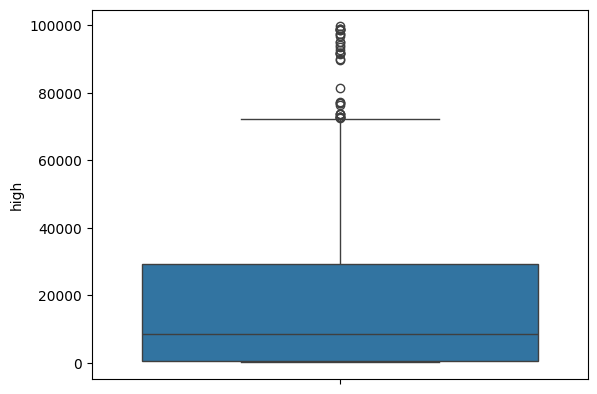

In [218]:
columns = df.select_dtypes(include="float").columns.to_list()
columns
sns.boxplot(df[columns[3]])

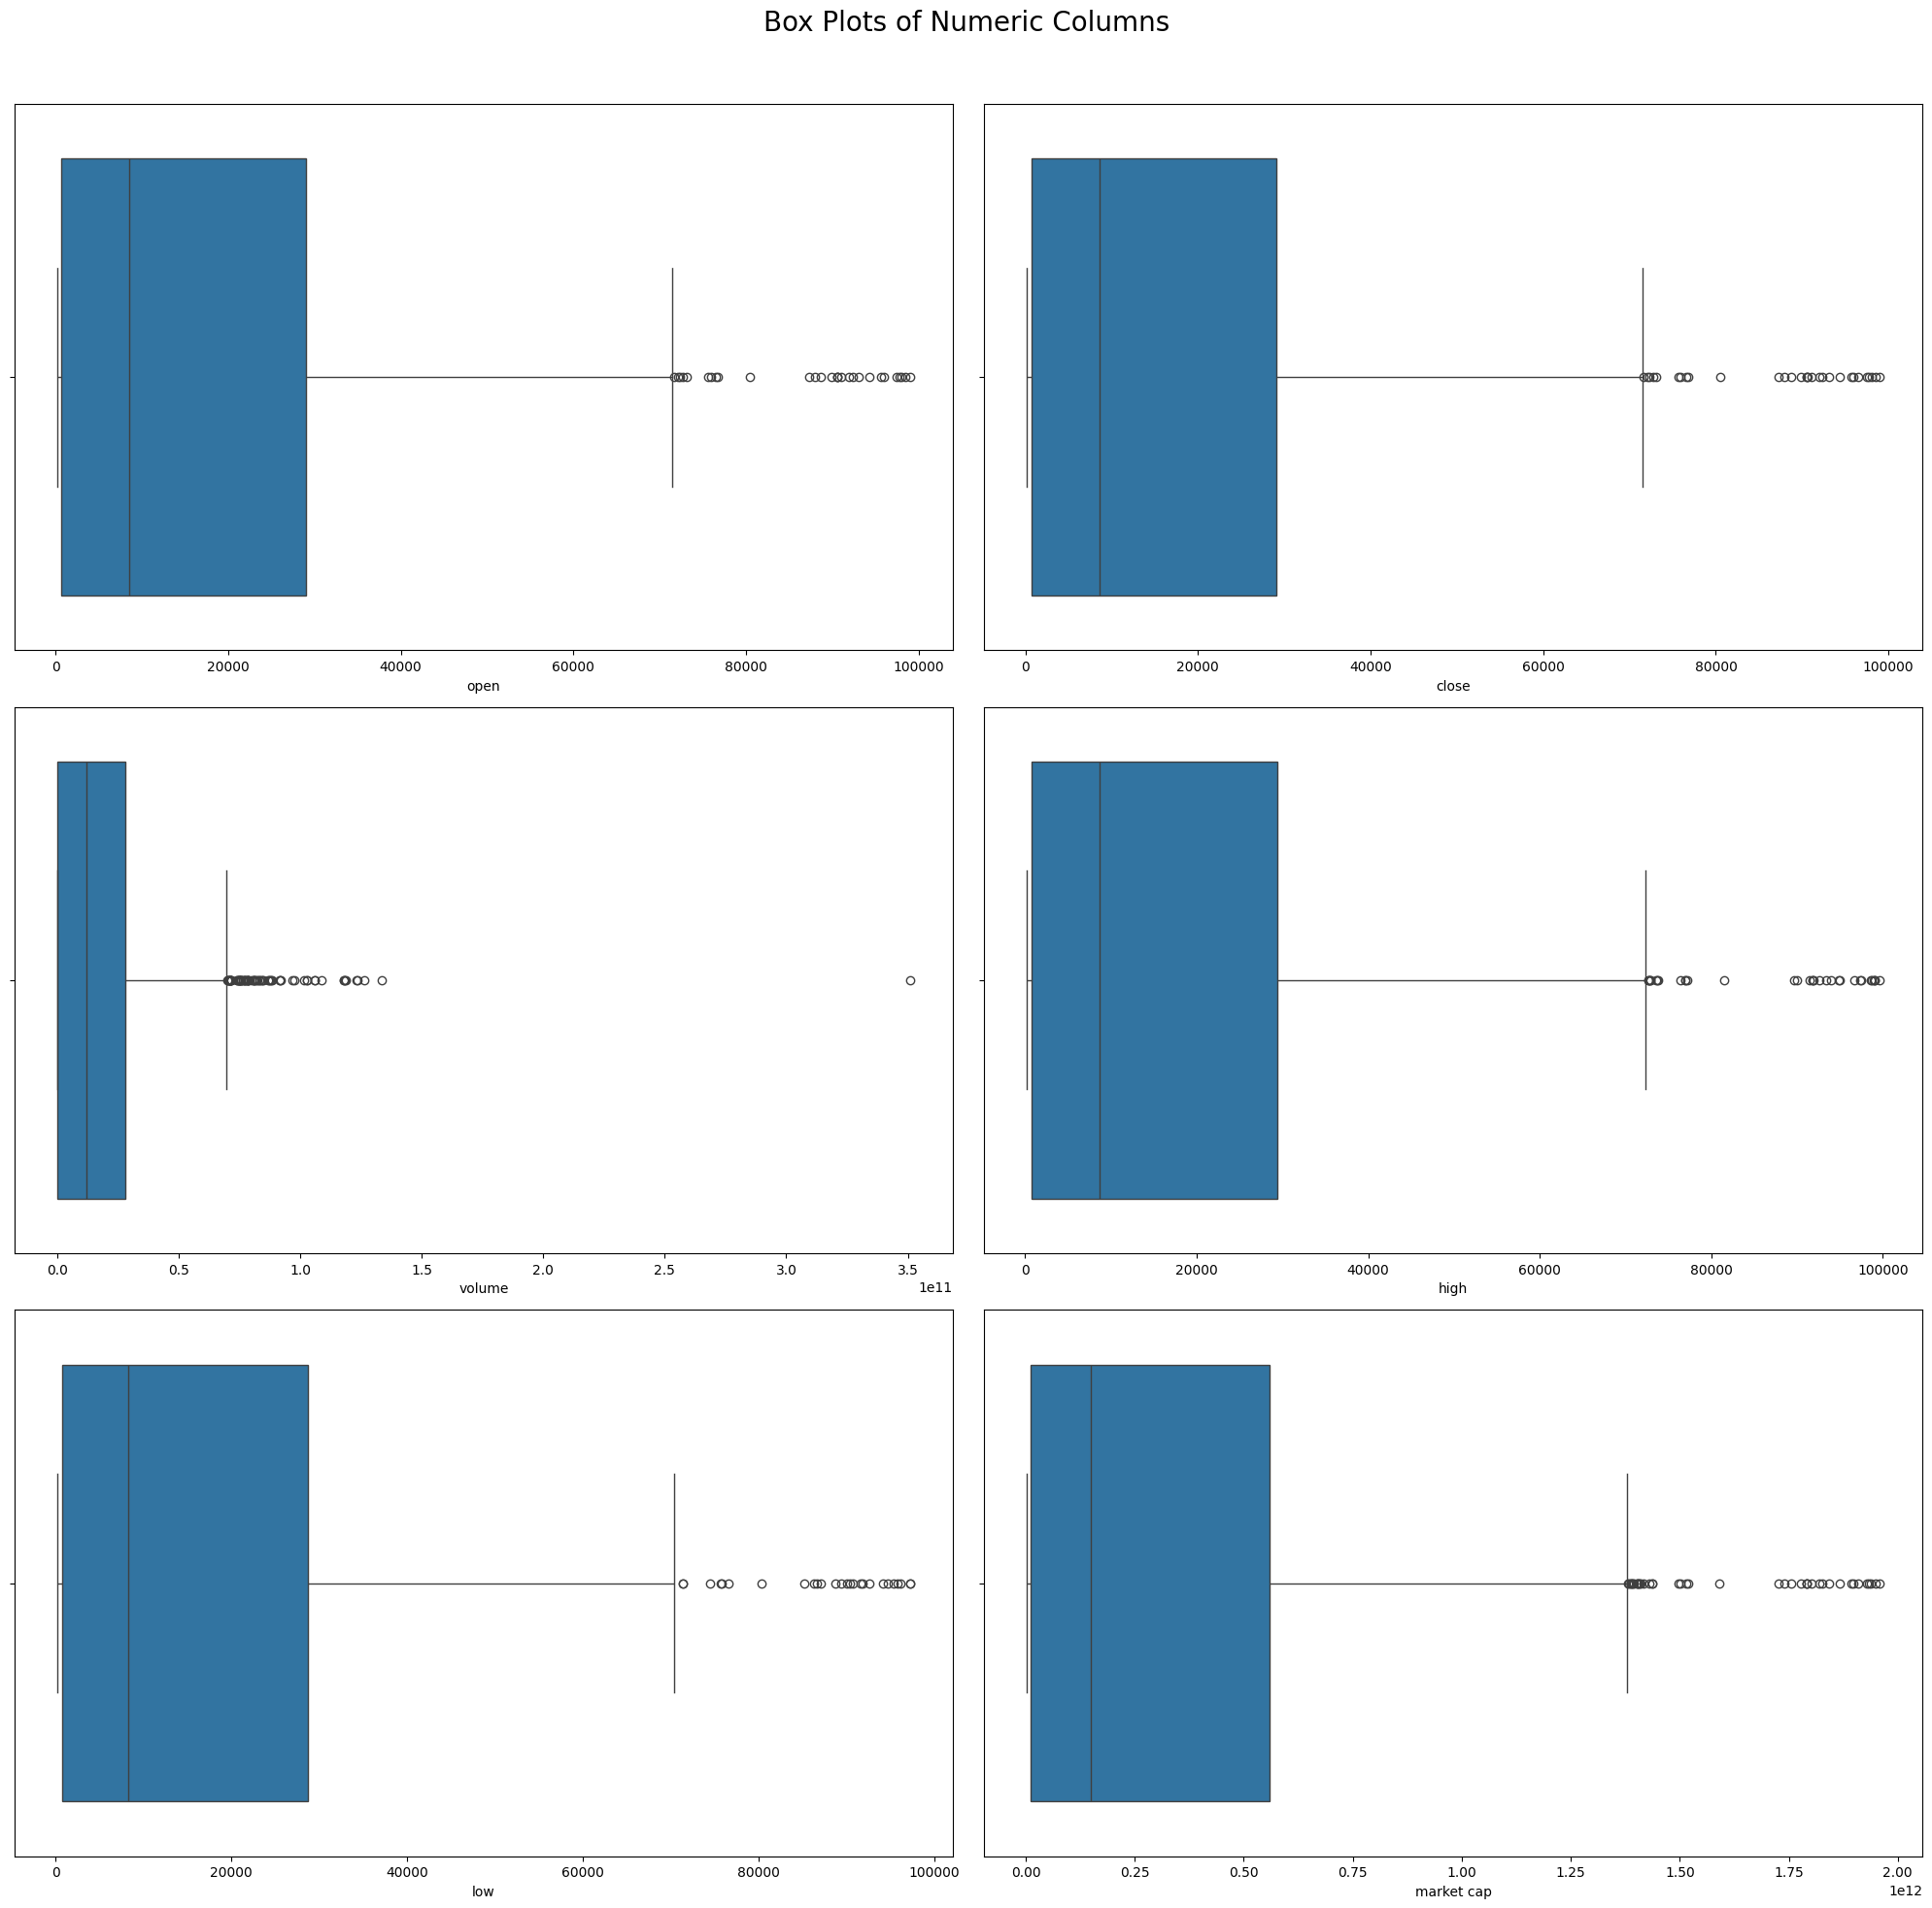

In [251]:
columns = df.select_dtypes(include="float").columns.to_list()

fig, axes = plt.subplots(int(len(columns)//2), 2, figsize=(20, 20))  
fig.suptitle("Box Plots of Numeric Columns", fontsize=20) 
axes = axes.flatten() 
for index, col in enumerate(columns):  
    sns.boxplot(data=df, x=col, ax=axes[index])  # Use correct syntax


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig.savefig("boxplots.svg", format="svg")

    

In [254]:
df["date"] = pd.to_datetime(df["date"])

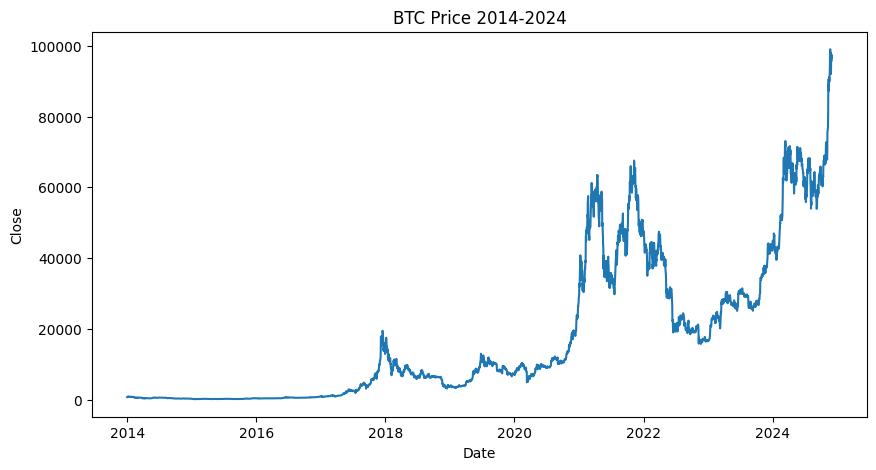

In [263]:
fig = plt.figure(figsize=(10,5))

sns.lineplot(data=df, x="date", y="close")
plt.title("BTC Price 2014-2024")
plt.xlabel("Date")
plt.ylabel("Close")
plt.show()
fig.savefig("btc.svg", format="svg")

In [ ]:
df["date"].max()

Timestamp('2024-11-30 00:00:00+0000', tz='UTC')

<h1> 2) Predictors </h1>

In [264]:
df['Year_Week'] = df['date'].dt.strftime('%Y-%W')

first_week_day = df.groupby("Year_Week")["date"].idxmin() 
last_week_day = df.groupby("Year_Week")["date"].idxmax()

In [265]:
MCAP = df.loc[last_week_day]
df["MCAP"] = np.log(MCAP["market cap"])

df["MCAP"] = df.groupby("Year_Week")["MCAP"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    


/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/4214954205.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["MCAP"] = df.groupby("Year_Week")["MCAP"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [266]:
MCAP["year"] = MCAP["date"].dt.strftime("%Y")
test = MCAP.groupby("year").count()

In [267]:
PRC = df.loc[last_week_day]
df["PRC"] = np.log(PRC["close"])
df["PRC"] = df.groupby("Year_Week")["PRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/1108071729.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["PRC"] = df.groupby("Year_Week")["PRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [268]:
max_price_week = df.groupby("Year_Week")["close"].idxmax()
df["MAXDPRC"] = df.loc[max_price_week, "close"]
df["MAXDPRC"] = df.groupby("Year_Week")["MAXDPRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))    


/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/439710787.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["MAXDPRC"] = df.groupby("Year_Week")["MAXDPRC"].transform(lambda x: x.fillna(method="ffill").fillna(method="bfill"))


In [269]:
def get_past_n_week_return(n, row):
    current_index = row.name
    past_index = current_index - n
    try: 
        ret = df.loc[current_index, "close"] - df.loc[past_index, "close"]
    except: 
        ret = np.nan

    return ret

In [270]:
df["past_one_week_return"] = df.apply(lambda x: get_past_n_week_return(6, x), axis=1)
df["past_two_week_return"] = df.apply(lambda x: get_past_n_week_return(13, x), axis=1)

In [271]:
#more efficient way

df["r_1"] = df["close"].diff(6)
df["r_2"] = df["close"].diff(13)
df["r_3"] = df["close"].diff(20)
df["r_4"] = df["close"].diff(27)
df["r_4_1"] = df["r_4"] - df["r_1"]
df["rel_daily_return"] = -(df["close"].diff(-1)) / df["close"]

In [272]:
PRCVOL = np.log(df.groupby("Year_Week")["volume"].mean()) 
df = pd.merge(df, PRCVOL.rename("PRCVOL"), left_on="Year_Week", right_index=True, how="left")

In [273]:
STDPRCVOL = np.log(df.groupby("Year_Week")["volume"].std()) 
df = pd.merge(df, STDPRCVOL.rename("STDPRCVOL"), left_on="Year_Week", right_index=True, how="left")


In [274]:
abs_avg_daily_return = df["rel_daily_return"].abs().groupby(df["Year_Week"]).mean()

DAMIHUD = abs_avg_daily_return / PRCVOL

df = pd.merge(df, DAMIHUD.rename("DAMIHUD"), left_on="Year_Week", right_index=True, how="left")

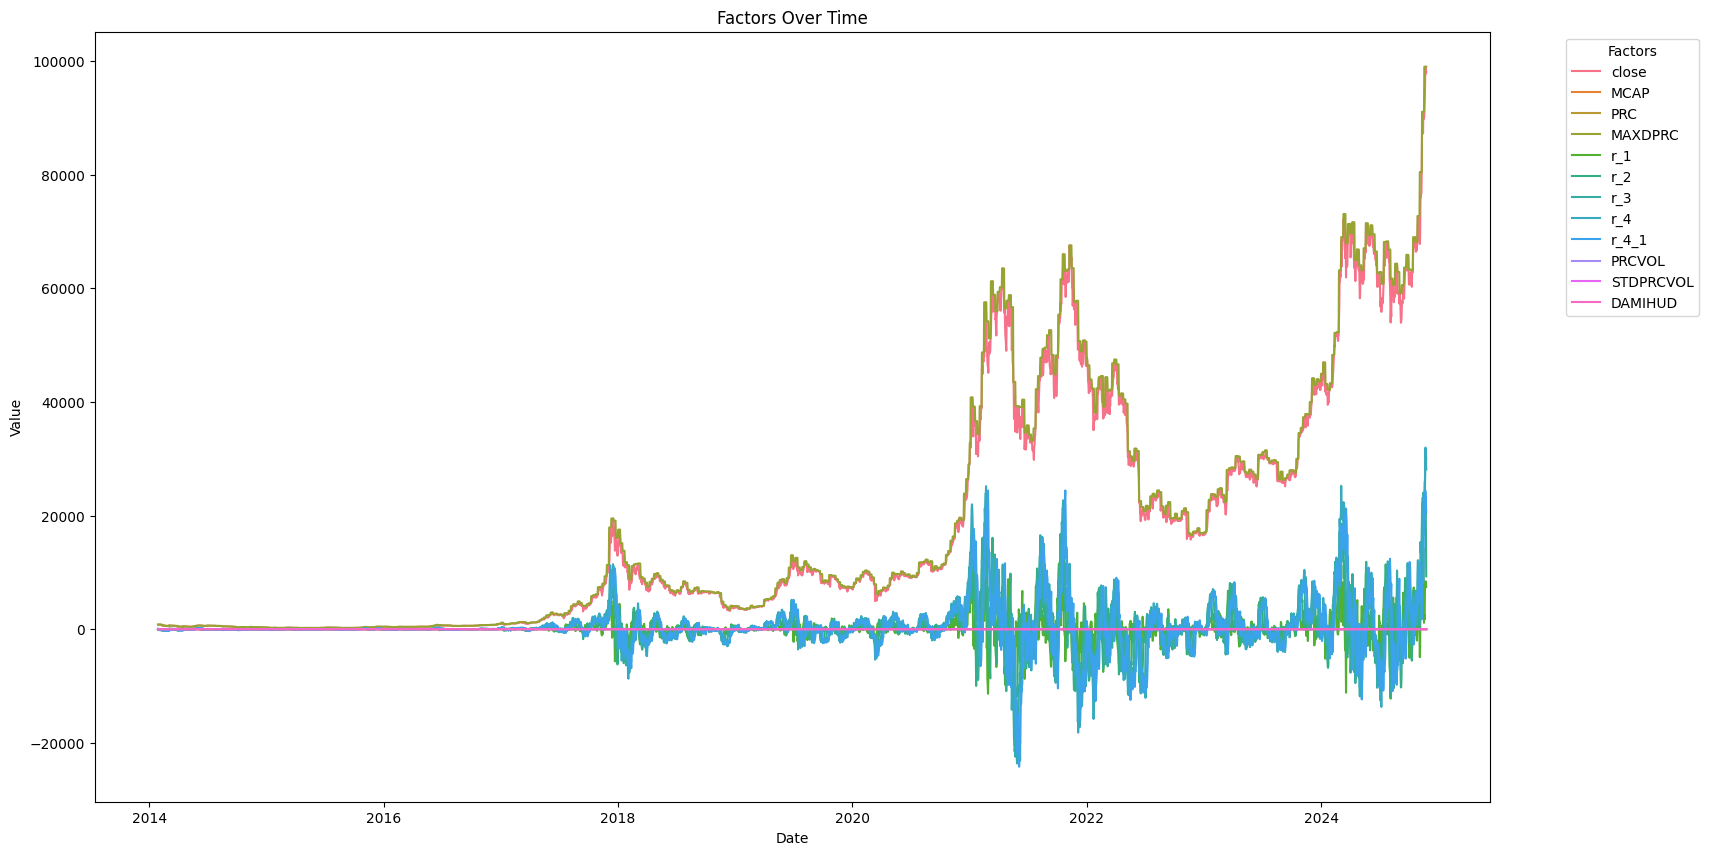

In [295]:
df_factors_exclude_seven = df_factors.drop(["seven_day_return"], axis=1)

df_melted = df_factors_exclude_seven.melt(id_vars=["date"], var_name="Factor", value_name="Value")

fig = plt.figure(figsize=(18, 10))
sns.lineplot(data=df_melted, x="date", y="Value", hue="Factor")

plt.title("Factors Over Time")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend(title="Factors", bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

fig.savefig("factors.svg", format="svg")

<h1> 3) Seven Day Return </h1>

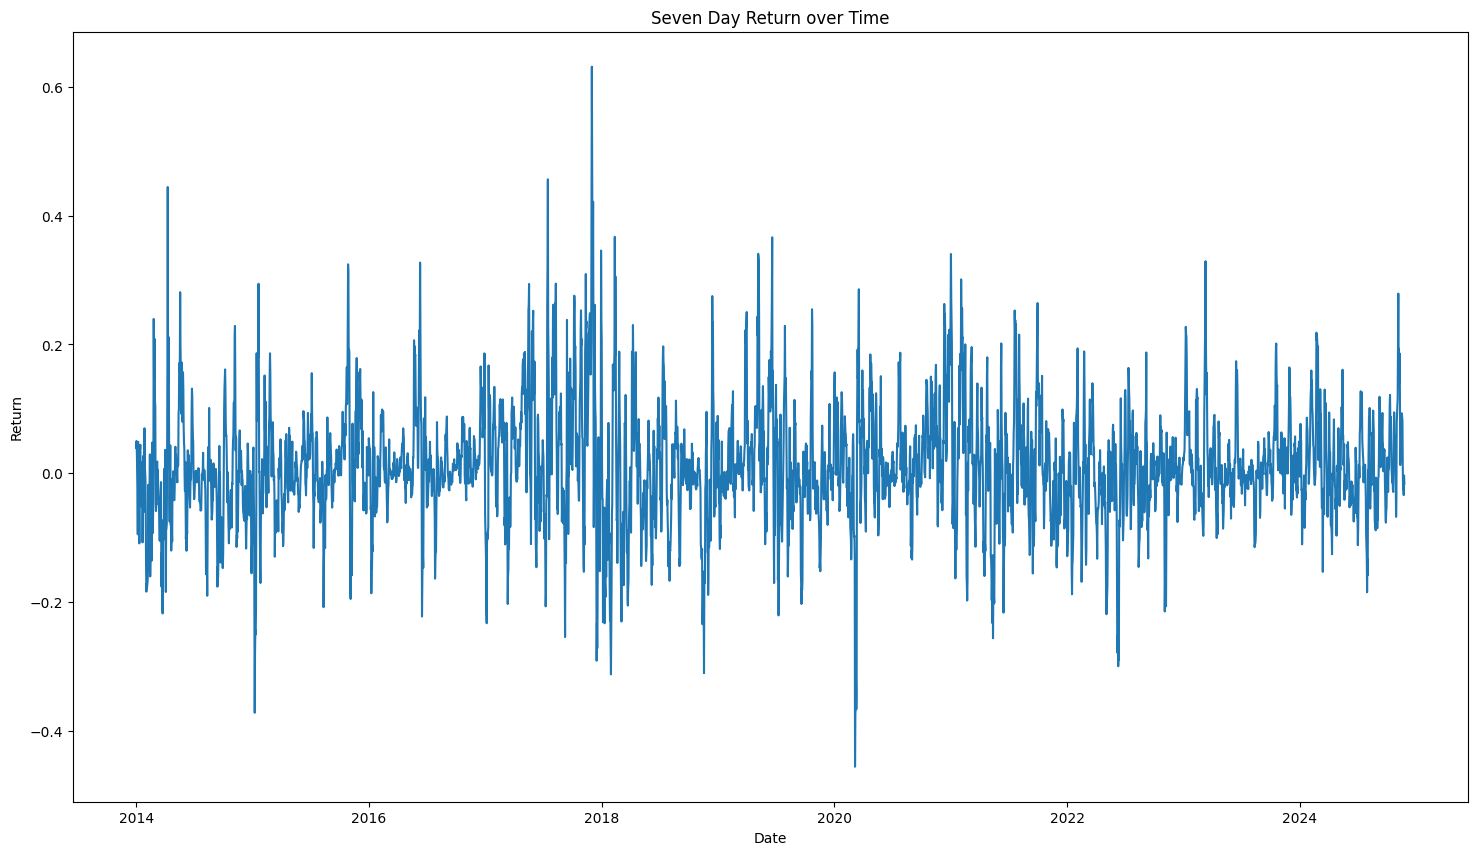

In [306]:
df["seven_day_return"] = (-1*(df["close"].diff(-6))) / df["close"]

fig = plt.figure(figsize=(18, 10))
sns.lineplot(data=df, x="date", y="seven_day_return")

plt.title("Seven Day Return over Time")
plt.xlabel("Date")
plt.ylabel("Return")


plt.show()

fig.savefig("sevendayreturn.svg", format="svg")


<h1> 4) Log Reg, Random Forest, SVM </h1>

In [312]:
df_price_vol = df.copy(deep=True)
sample = df_price_vol[df_price_vol["date"] <= "2022-12-31 00:00:00+00:00"]
out_of_sample = df_price_vol[df_price_vol["date"] > "2022-12-31 00:00:00+00:00"]

sample = sample[["open", "close", "high", "low", "volume", "seven_day_return"]]
sample.dropna(inplace=True)


out_of_sample = out_of_sample[["open", "close", "high", "low", "volume", "seven_day_return"]]
out_of_sample.dropna(inplace=True)

sample.dropna(inplace=True)
out_of_sample.dropna(inplace=True)

y=sample["seven_day_return"]
X = sample.drop(["seven_day_return"], axis=1)

In [319]:
# Time Series Split (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

# Define pipeline: Scaling + Model
pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", Ridge())  # Ridge regression (L2-regularized)
])

# Define hyperparameter grid (alpha is the regularization strength)
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Define multiple scoring metrics
scoring = {
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search.fit(X, y)

# Extract best parameters and scores
best_params = grid_search.best_params_
best_mse = -grid_search.best_score_  # Convert negative MSE back to positive
best_r2 = grid_search.cv_results_["mean_test_R2"][grid_search.best_index_]  # Correctly fetch R²

print("Best Parameters:", best_params)
print("Best Score (MSE):", best_mse)
print("Best Score (R²):", best_r2)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END .................................model__alpha=0.001; total time=   0.1s
[CV] END .................................model__alpha=0.001; total time=   0.1s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.1s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model

In [320]:
# Define pipeline: Scaling + Random Forest
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Define hyperparameter grid
param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search_rf.fit(X, y)

# Extract best parameters and scores
best_params_rf = grid_search_rf.best_params_
best_mse_rf = -grid_search_rf.best_score_  # Convert negative MSE back to positive
best_r2_rf = grid_search_rf.cv_results_["mean_test_R2"][grid_search_rf.best_index_]

print("Best RF Parameters:", best_params_rf)
print("Best RF Score (MSE):", best_mse_rf)
print("Best RF Score (R²):", best_r2_rf)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   1.0s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   0.9s
[CV] EN

In [321]:
# Define pipeline: Scaling + SVM
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

# Define hyperparameter grid
param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.01, 0.1, 0.5],
    "model__kernel": ["linear", "rbf"]
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search_svm = GridSearchCV(
    pipeline_svm, param_grid_svm, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search_svm.fit(X, y)

# Extract best parameters and scores
best_params_svm = grid_search_svm.best_params_
best_mse_svm = -grid_search_svm.best_score_  # Convert negative MSE back to positive
best_r2_svm = grid_search_svm.cv_results_["mean_test_R2"][grid_search_svm.best_index_]

print("Best SVM Parameters:", best_params_svm)
print("Best SVM Score (MSE):", best_mse_svm)
print("Best SVM Score (R²):", best_r2_svm)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.2s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=rbf; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=rbf; total time=   0.0s
[CV] END model__C=0.1,

<h1> 5) Prediction based on Factors

In [110]:
df_factors = df[["date","close", "MCAP", "PRC", "MAXDPRC", "r_1", "r_2", "r_3", "r_4", "r_4_1", "PRCVOL", "STDPRCVOL", "DAMIHUD", "seven_day_return"]]

In [111]:
scaler = StandardScaler() 

In [131]:
df_factors.dropna(inplace=True)
sample = df_factors[df_factors["date"] <= "2022-12-31 00:00:00+00:00"]

out_of_sample = df_factors[df_factors["date"] > "2022-12-31 00:00:00+00:00"]

sample.dropna(inplace=True)
out_of_sample.dropna(inplace=True)

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/3827882100.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_factors.dropna(inplace=True)
/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/3827882100.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample.dropna(inplace=True)
/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/3827882100.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [116]:
y = sample.drop(["date", "close"], axis=1)["seven_day_return"]
X = sample.drop(["seven_day_return", "date", "close"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [27]:
y = sample.drop(["date", "close"], axis=1)["seven_day_return"]
X = sample.drop(["seven_day_return", "date", "close"], axis=1)

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)


for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"Split R^2 Score: {r2:.4f}")


Split R^2 Score: -0.5485
Split R^2 Score: -1.2198
Split R^2 Score: -0.3824
Split R^2 Score: -0.5879
Split R^2 Score: -0.2898


In [132]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

y = sample.drop(["date", "close"], axis=1)["seven_day_return"]
X= sample.drop(["seven_day_return", "date", "close"], axis=1)


pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42))  
])

param_grid = {
    "rf__n_estimators": [50, 100, 200],   
    "rf__max_depth": [5, 10, None],       
    "rf__min_samples_split": [2, 5, 10],  
    "rf__min_samples_leaf": [1, 2, 4]     
}


grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=2
)


grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best R^2 Score:", grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.1s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.4s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.4s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.5s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.6s
[CV] END rf__ma

In [119]:
best_model = grid_search.best_estimator_

In [ ]:
# Extract the best parameters from GridSearchCV
best_params = grid_search.best_params_

# Train a new pipeline with the best parameters
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42, 
                                 n_estimators=best_params["rf__n_estimators"],
                                 max_depth=best_params["rf__max_depth"],
                                 min_samples_split=best_params["rf__min_samples_split"],
                                 min_samples_leaf=best_params["rf__min_samples_leaf"]))  
])

# Fit the new pipeline on the full dataset
best_pipeline.fit(X, y)



Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=4,
                                       n_estimators=200, random_state=42))])

In [133]:
def buy(btc, cash, close): 
    if not cash == 0: 
        btc = cash / close 
        cash = 0
    return btc, cash 

def sell(btc, cash, close): 
    if not btc == 0: 
        cash = btc * close
        btc = 0
    return btc, cash 

In [135]:
cash = 100000
btc = 0

track_records = []
seven_day_pred = []


for index, row in out_of_sample.iterrows():

    scaling = row.drop(["seven_day_return", "date", "close"])  
    scaling = pd.DataFrame([scaling])  
    scaling = pd.DataFrame(scaling, columns=scaler.feature_names_in_, index=[index])

    features = scaling[['MCAP', 'PRC', 'MAXDPRC', 'r_1', 'r_2', 'r_3', 'r_4', 'r_4_1', 'PRCVOL','STDPRCVOL', 'DAMIHUD']]

    prediction = best_model.predict(pd.DataFrame(features))[0]
    seven_day_pred.append(prediction)
    if prediction >= 0:
        btc, cash = buy(btc, cash, row["close"])
    else:
        btc, cash = sell(btc, cash, row["close"])

    value = btc * row["close"] if cash == 0 else cash
    track_records.append({"date": row["date"], "value": value, "prediction": prediction})

track_records = pd.DataFrame(track_records)

In [139]:
start_price = out_of_sample.iloc[0]["close"]
end_price = out_of_sample.iloc[-1]["close"]

buy_and_hold_return = (100000 / start_price) * end_price


In [140]:
print("Final Result: ")
print(50*"-")
print("with prediction strategy")
print(50*"-")
print("Cash: ", cash)
print("BTC: ", btc)
print("BTC value: ", btc * out_of_sample.iloc[-1]["close"])
print(50*"-")
print("with buy and hold strategy")
print(50*"-")
print(buy_and_hold_return)


Final Result: 
--------------------------------------------------
with prediction strategy
--------------------------------------------------
Cash:  335786.7014620679
BTC:  0
BTC value:  0.0
--------------------------------------------------
with buy and hold strategy
--------------------------------------------------
587314.5526373723


In [141]:
buy_and_hold_value = out_of_sample.copy(deep=True)
buy_and_hold_value["buy_and_hold"] = buy_and_hold_value["close"] * (100000/start_price)

In [142]:
track = pd.merge(track_records, pd.DataFrame(buy_and_hold_value)[["buy_and_hold", "date"]], on="date", how="left")

In [143]:
print(track.head())

                       date          value  prediction   buy_and_hold
0 2023-01-02 00:00:00+00:00  100000.000000    0.000052  100000.000000
1 2023-01-03 00:00:00+00:00   99948.381851   -0.000109   99948.381851
2 2023-01-04 00:00:00+00:00   99948.381851    0.000866  101047.231327
3 2023-01-05 00:00:00+00:00   99791.306858    0.002267  100888.429424
4 2023-01-06 00:00:00+00:00  100474.291864    0.002353  101578.923284


(array([19358., 19448., 19539., 19631., 19723., 19814., 19905., 19997.]),
 [Text(19358.0, 0, '2023-01'),
  Text(19448.0, 0, '2023-04'),
  Text(19539.0, 0, '2023-07'),
  Text(19631.0, 0, '2023-10'),
  Text(19723.0, 0, '2024-01'),
  Text(19814.0, 0, '2024-04'),
  Text(19905.0, 0, '2024-07'),
  Text(19997.0, 0, '2024-10')])

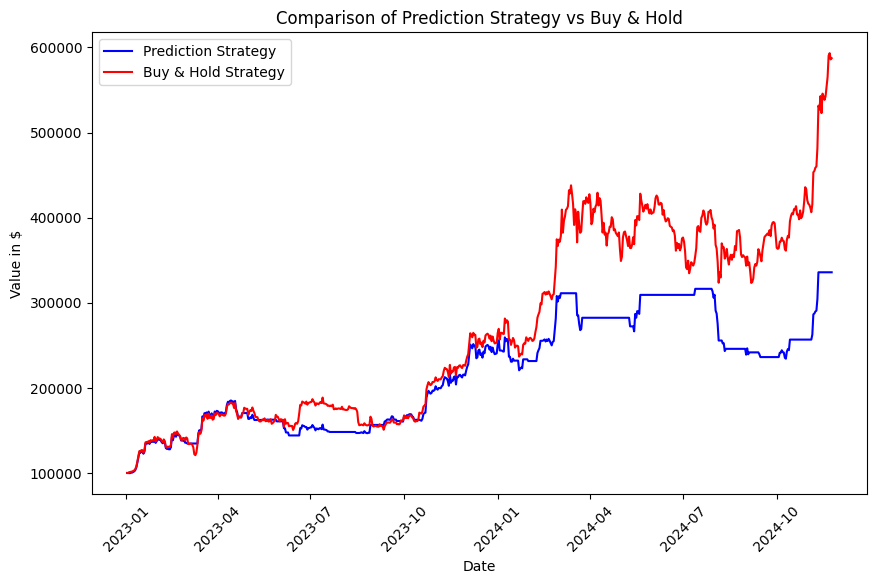

In [144]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=track, x="date", y="value", label="Prediction Strategy", color="blue")
sns.lineplot(data=track, x="date", y="buy_and_hold", label="Buy & Hold Strategy", color="red")

plt.xlabel("Date")
plt.ylabel("Value in $")
plt.title("Comparison of Prediction Strategy vs Buy & Hold")
plt.legend()
plt.xticks(rotation=45)


<h1> Verify Methodology on samples < 2020 <h1>

The peak in 2024 could be a key factor contributing to the poor performance and low R² score. Since the model was trained on data up to 2023, it may struggle to generalize to 2024 if the data deviates significantly from prior trends. This discrepancy suggests that the model is unable to capture the underlying patterns driving the 2024 peak, leading to suboptimal predictions.

In [155]:
df_factors.dropna(inplace=True)
verification = df_factors[df_factors["date"] <= "2021-12-31 00:00:00+00:00"]

sample = verification[verification["date"] <= "2019-12-31 00:00:00+00:00"]

out_of_sample = verification[verification["date"] > "2019-12-31 00:00:00+00:00"]

sample.dropna(inplace=True)
out_of_sample.dropna(inplace=True)

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/3096881471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_factors.dropna(inplace=True)
/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/3096881471.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample.dropna(inplace=True)
/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_47647/3096881471.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [156]:
y = sample.drop(["date", "close"], axis=1)["seven_day_return"]
X= sample.drop(["seven_day_return", "date", "close"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [157]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

y = sample.drop(["date", "close"], axis=1)["seven_day_return"]
X= sample.drop(["seven_day_return", "date", "close"], axis=1)


pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42))  
])

param_grid = {
    "rf__n_estimators": [50, 100, 200],   
    "rf__max_depth": [5, 10, None],       
    "rf__min_samples_split": [2, 5, 10],  
    "rf__min_samples_leaf": [1, 2, 4]     
}


grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=2
)


grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best R^2 Score:", grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.1s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.4s
[CV] END rf__ma

In [158]:
best_model = grid_search.best_estimator_

In [159]:
# Extract the best parameters from GridSearchCV
best_params = grid_search.best_params_

# Train a new pipeline with the best parameters
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42, 
                                 n_estimators=best_params["rf__n_estimators"],
                                 max_depth=best_params["rf__max_depth"],
                                 min_samples_split=best_params["rf__min_samples_split"],
                                 min_samples_leaf=best_params["rf__min_samples_leaf"]))  
])

# Fit the new pipeline on the full dataset
best_pipeline.fit(X, y)

# Now `best_pipeline` is your final trained model


Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=4,
                                       n_estimators=200, random_state=42))])

In [160]:
def buy(btc, cash, close): 
    if not cash == 0: 
        btc = cash / close 
        cash = 0
    return btc, cash 

def sell(btc, cash, close): 
    if not btc == 0: 
        cash = btc * close
        btc = 0
    return btc, cash 

In [161]:
cash = 100000
btc = 0

track_records = []
seven_day_pred = []


for index, row in out_of_sample.iterrows():

    scaling = row.drop(["seven_day_return", "date", "close"])  
    scaling = pd.DataFrame([scaling])  
    #scaler = grid_search.best_estimator_.named_steps['scaler']
    scaling = pd.DataFrame(scaling, columns=scaler.feature_names_in_, index=[index])

    features = scaling[['MCAP', 'PRC', 'MAXDPRC', 'r_1', 'r_2', 'r_3', 'r_4', 'r_4_1', 'PRCVOL','STDPRCVOL', 'DAMIHUD']]

    prediction = best_pipeline.predict(pd.DataFrame(features))[0]
    seven_day_pred.append(prediction)

    if prediction >= 0:
        btc, cash = buy(btc, cash, row["close"])
    else:
        btc, cash = sell(btc, cash, row["close"])

    value = btc * row["close"] if cash == 0 else cash
    track_records.append({"date": row["date"], "value": value, "prediction": prediction})

track_records = pd.DataFrame(track_records)

In [162]:
start_price = out_of_sample.iloc[0]["close"]
end_price = out_of_sample.iloc[-1]["close"]

buy_and_hold_return = (100000 / start_price) * end_price


In [163]:
print("Final Result: ")
print(50*"-")
print("with prediction strategy")
print(50*"-")
print("Cash: ", cash)
print("BTC: ", btc)
print("BTC value: ", btc * out_of_sample.iloc[-1]["close"])
print(50*"-")
print("with buy and hold strategy")
print(50*"-")
print(buy_and_hold_return)

Final Result: 
--------------------------------------------------
with prediction strategy
--------------------------------------------------
Cash:  213541.8846712185
BTC:  0
BTC value:  0.0
--------------------------------------------------
with buy and hold strategy
--------------------------------------------------
643129.5075994141


In [164]:
buy_and_hold_value = out_of_sample.copy(deep=True)
buy_and_hold_value["buy_and_hold"] = buy_and_hold_value["close"] * (100000/start_price)

buy_and_hold_value

,date,close,MCAP,PRC,MAXDPRC,r_1,r_2,r_3,r_4,r_4_1,PRCVOL,STDPRCVOL,DAMIHUD,seven_day_return,buy_and_hold
2191,2020-01-01 00:00:00+00:00,7200.174393,25.624607,8.910763,7411.317327,-38.792632,-2.669971,-42.959970,-248.133128,-209.340496,23.773946,22.114314,0.001166,0.133819,100000.000000
2192,2020-01-02 00:00:00+00:00,6985.470001,25.624607,8.910763,7411.317327,-304.618517,-233.346386,-284.214558,-561.526697,-256.908180,23.773946,22.114314,0.001166,0.156667,97018.066782
2193,2020-01-03 00:00:00+00:00,7344.884183,25.624607,8.910763,7411.317327,26.894149,153.725714,220.210213,-211.353851,-238.248000,23.773946,22.114314,0.001166,0.072729,102009.809514
2194,2020-01-04 00:00:00+00:00,7410.656566,25.624607,8.910763,7411.317327,-11.996023,-100.932476,258.354722,-153.688837,-141.692814,23.773946,22.114314,0.001166,0.102001,102923.292708
2195,2020-01-05 00:00:00+00:00,7411.317327,25.624607,8.910763,7411.317327,118.322249,55.689060,478.836937,10.417971,-107.904278,23.773946,22.114314,0.001166,0.084495,102932.469722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2917,2021-12-27 00:00:00+00:00,50640.418800,27.498562,10.743036,50640.418800,1703.804650,4027.785290,-59.665540,-6365.006670,-8068.811320,24.134180,22.348319,0.001230,-0.065071,703322.114659
2918,2021-12-28 00:00:00+00:00,47588.854780,27.498562,10.743036,50640.418800,-1039.655150,-1307.866050,-2915.940760,-9640.975120,-8601.319970,24.134180,22.348319,0.001230,-0.023761,660940.307588
2919,2021-12-29 00:00:00+00:00,46444.710490,27.498562,10.743036,50640.418800,-4339.827690,-1220.715590,-1227.411900,-10033.106990,-5693.279300,24.134180,22.348319,0.001230,-0.011780,645049.799560
2920,2021-12-30 00:00:00+00:00,47178.125840,27.498562,10.743036,50640.418800,-3644.070680,975.982460,-65.179840,-6420.120630,-2776.049950,24.134180,22.348319,0.001230,-0.076500,655235.877146


In [165]:
track = pd.merge(track_records, pd.DataFrame(buy_and_hold_value)[["buy_and_hold", "date"]], on="date", how="left")

(array([18262., 18353., 18444., 18536., 18628., 18718., 18809., 18901.,
        18993.]),
 [Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04'),
  Text(18444.0, 0, '2020-07'),
  Text(18536.0, 0, '2020-10'),
  Text(18628.0, 0, '2021-01'),
  Text(18718.0, 0, '2021-04'),
  Text(18809.0, 0, '2021-07'),
  Text(18901.0, 0, '2021-10'),
  Text(18993.0, 0, '2022-01')])

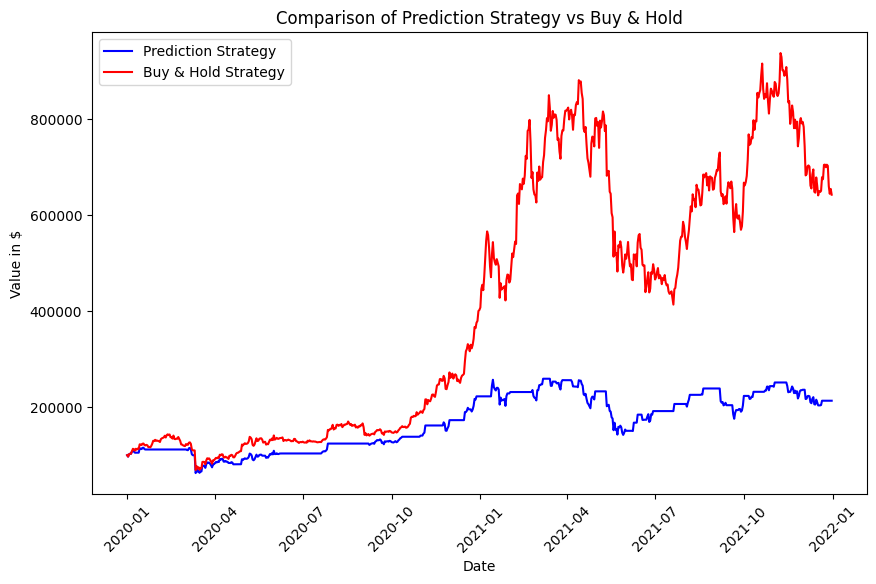

In [166]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=track, x="date", y="value", label="Prediction Strategy", color="blue")
sns.lineplot(data=track, x="date", y="buy_and_hold", label="Buy & Hold Strategy", color="red")

plt.xlabel("Date")
plt.ylabel("Value in $")
plt.title("Comparison of Prediction Strategy vs Buy & Hold")
plt.legend()
plt.xticks(rotation=45)


<h1> Backup </h1>

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Generate a large dataset
size = 10000


# Define the row-wise function
def get_past_n_week_return(n, row):
    current_index = row.name
    past_index = current_index - n
    try: 
        ret = df.loc[current_index, "close"] - df.loc[past_index, "close"]
    except: 
        ret = np.nan
    return ret

# Test different values of n
n_values = [10, 100, 1000, 10000, 100000, 1000000]
no_lamb = []
lamb = []

test = df.copy(deep=True)
for n in n_values:
    # Measure time for diff()
    start = time.time()
    abs_avg_daily_return = test["rel_abs_daily_return"].abs().groupby(test["Year_Week"]).mean()
    try: 
        total_time = no_lamb[-1]+ (time.time()-start)
    except: 
        total_time = 0 + (time.time()-start)
    
    no_lamb.append(total_time)

    # Measure time for apply()
    start = time.time()
    abs_avg_daily_return = test.groupby("Year_Week")["rel_abs_daily_return"].apply(lambda x: x.abs().mean())
    try: 
        total_time = lamb[-1] + (time.time()-start)
    except: 
        total_time = 0 + (time.time()-start)
        
    lamb.append(total_time)

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(n_values, no_lamb, marker="o", label="no lambda(n) - Vectorized")
plt.plot(n_values, lamb, marker="o", label="lambda() - Row-wise")
plt.xlabel("n (Lag weeks)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Efficiency: diff() vs. apply()")
plt.legend()
plt.grid()
plt.show()


In [516]:
real_btc_course = out_of_sample[["date", "close"]]
real_btc_course_mean = real_btc_course["close"].mean()
real_btc_course_std = real_btc_course["close"].std()
real_btc_course_scaled = real_btc_course.copy(deep=True)
real_btc_course_scaled["close"] = (real_btc_course["close"] - real_btc_course_mean) / real_btc_course_std


(array([19358., 19448., 19539., 19631., 19723., 19814., 19905., 19997.]),
 [Text(19358.0, 0, '2023-01'),
  Text(19448.0, 0, '2023-04'),
  Text(19539.0, 0, '2023-07'),
  Text(19631.0, 0, '2023-10'),
  Text(19723.0, 0, '2024-01'),
  Text(19814.0, 0, '2024-04'),
  Text(19905.0, 0, '2024-07'),
  Text(19997.0, 0, '2024-10')])

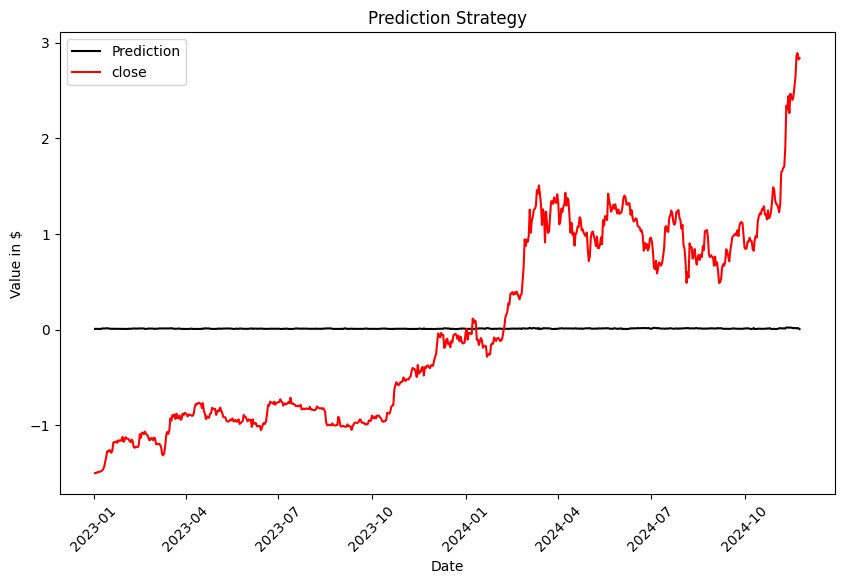

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=track, x="date", y="prediction", label="Prediction", color="black")
sns.lineplot(data=real_btc_course_scaled, x="date", y="close", label="close", color="red")

plt.xlabel("Date")
plt.ylabel("Value in $")
plt.title("Prediction Strategy")
plt.legend()
plt.xticks(rotation=45)
